### Importación de librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from tabulate import tabulate
from itertools import product

# Modelos de Machine Learning
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import xgboost as xgb

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Model Selection y Validación
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve, validation_curve
)

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

### Cargar datos

In [2]:
df_limpio = pd.read_csv('../data/stg/IA_PROPENSITY_TRAIN_1.csv', index_col=0) 
df_limpio.head()

,TIPO_CARROCERIA,COMBUSTIBLE,Potencia,TRANS,FORMA_PAGO,ESTADO_CIVIL,GENERO,OcupaciOn,PROVINCIA,Campanna1,...,Zona_Renta,REV_Garantia,Averia_grave,QUEJA_CAC,COSTE_VENTA,km_anno,Mas_1_coche,Revisiones,Edad_Cliente,Tiempo
PRODUCTO,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,1,0,0,2,1,4,1,...,3,0,2,1,2892,0,0,2,18,0
0,0,0,1,1,0,0,1,1,47,0,...,3,1,4,0,1376,7187,0,2,53,0
0,0,0,1,1,3,0,2,1,30,0,...,2,0,4,0,1376,0,1,4,21,3
0,0,0,1,1,2,0,1,1,32,1,...,2,1,2,1,2015,7256,1,4,48,5
0,0,0,1,1,2,0,1,1,4,1,...,2,1,1,0,2015,11293,0,2,56,0


In [3]:
X = df_limpio.drop(columns=['Tiempo', 'Mas_1_coche']) 
y = df_limpio['Mas_1_coche']  # Objetivo

# Dividir los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Random Forest

,criterion,max_depth,min_samples_split,min_samples_leaf,n_estimators,accuracy,f1_score,recall,roc_auc,cv_recall
2,entropy,30,9,3,400,0.827501,0.834385,0.827501,0.921295,0.803227
0,entropy,30,9,3,300,0.827190,0.834083,0.827190,0.921116,0.802518
3,entropy,30,12,3,400,0.823566,0.830844,0.823566,0.921018,0.812361
1,entropy,30,12,3,300,0.823152,0.830426,0.823152,0.921117,0.812184


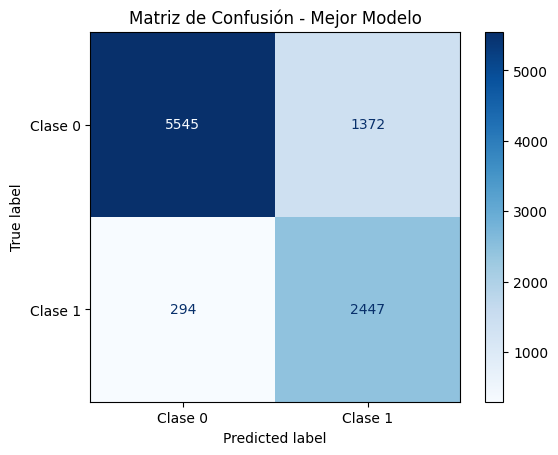

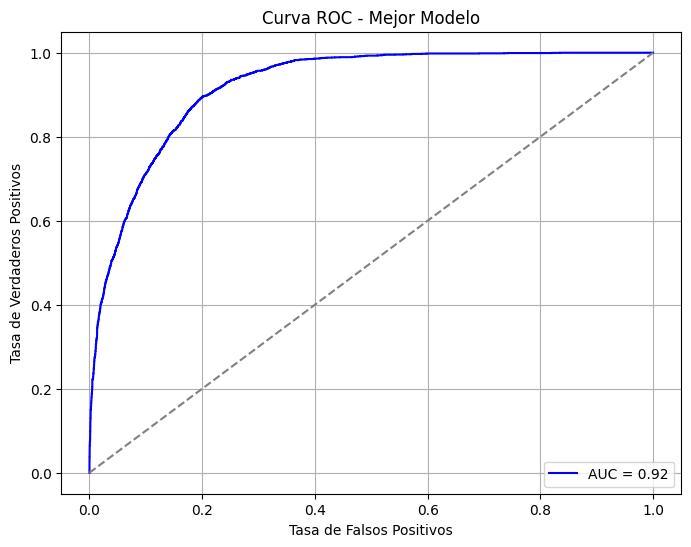

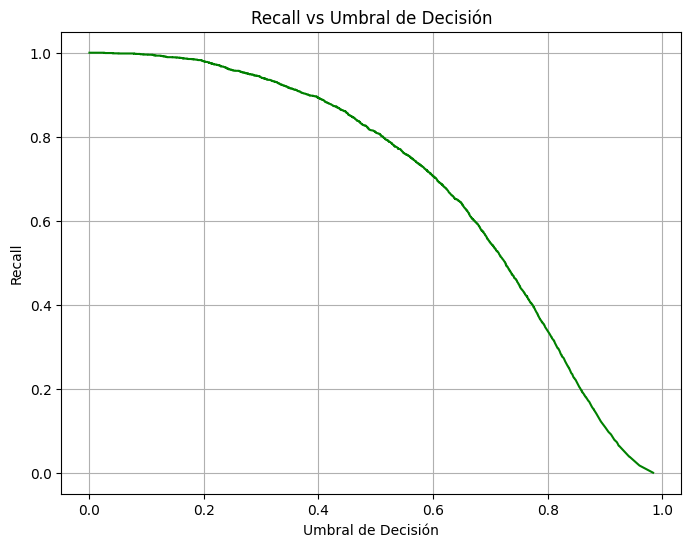

In [28]:
# Definir los parámetros de los modelos

param_grid = {
    'criterion': ['entropy'],
    'n_estimators': [300, 400],
    'max_depths' : [30],
    'min_samples_split': [9,12],
    'min_samples_leaf': [3]
}

# Almacenar los resultados

results = []

# Iterar sobre los parámetros

for params in product(*param_grid.values()):
    criterion, n_estimators, max_depth, min_samples_split, min_samples_leaf = params
    model = RandomForestClassifier(
        criterion=criterion,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced',
        random_state=42
    )

    # Entrenar el modelo

    model.fit(X_train, y_train)

    # Predecir el modelo en los datos de prueba

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.4).astype(int)

    # Calcular las métricas

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Validación cruzada

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    mean_cv_score = np.mean(cv_scores)
    
    # Guardar los resultados

    results.append({
        'criterion': criterion,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'n_estimators': n_estimators,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,  # <-- Priorizar recall
        'roc_auc': roc_auc,
        'cv_recall': mean_cv_score  # <-- Guardar recall en validación cruzada
    })


# Convertir los resultados en un DataFrame

results_df = pd.DataFrame(results).sort_values(by=['recall', 'f1_score'], ascending=False)

# Mostrar los resultados

display(results_df.head(5))

# Seleccionar el mejor modelo

best_model_params = results_df.iloc[0]
best_model = RandomForestClassifier(
    criterion=best_model_params['criterion'],
    n_estimators=best_model_params['n_estimators'],
    max_depth=best_model_params['max_depth'],
    min_samples_split=best_model_params['min_samples_split'],
    min_samples_leaf=best_model_params['min_samples_leaf'],
    class_weight='balanced',
    random_state=42
)

# Entrenar el mejor modelo

best_model.fit(X_train, y_train)

# Predecir el modelo en los datos de prueba

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.4).astype(int)


# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - Mejor Modelo')
plt.show()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'Curva ROC - Mejor Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Graficar Recall vs Umbral de decisión
plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr, label='Recall', color='green')
plt.title('Recall vs Umbral de Decisión')
plt.xlabel('Umbral de Decisión')
plt.ylabel('Recall')
plt.grid(True)
plt.show()

### XGBoost

,learning_rate,n_estimators,max_depth,scale_pos_weight,colsample_bytree,subsample,gamma,base_score,accuracy,f1_score,recall,roc_auc,cv_recall
4,0.05,800,10,1,0.8,0.8,0.1,0.5,0.862187,0.863568,0.862187,0.937521,0.728653
1,0.05,800,8,1,0.9,0.8,0.1,0.5,0.860944,0.862843,0.860944,0.938202,0.728564
5,0.05,800,10,1,0.9,0.8,0.1,0.5,0.858666,0.860083,0.858666,0.936438,0.728032
9,0.10,800,8,1,0.9,0.8,0.1,0.5,0.858563,0.859713,0.858563,0.934197,0.723331
0,0.05,800,8,1,0.8,0.8,0.1,0.5,0.858149,0.860219,0.858149,0.938354,0.729805


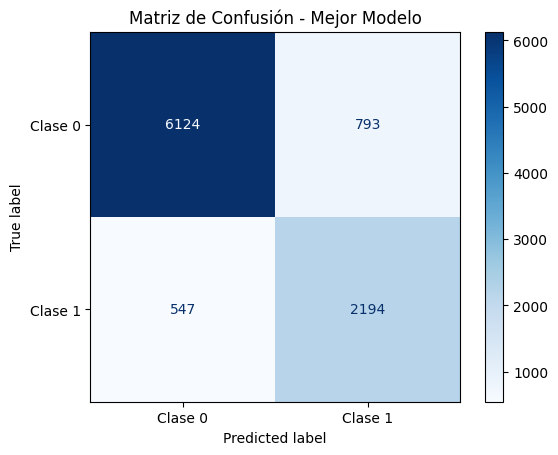

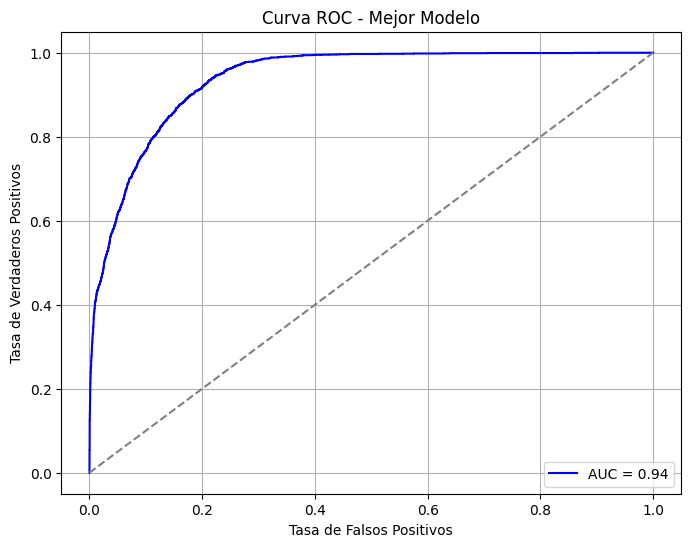

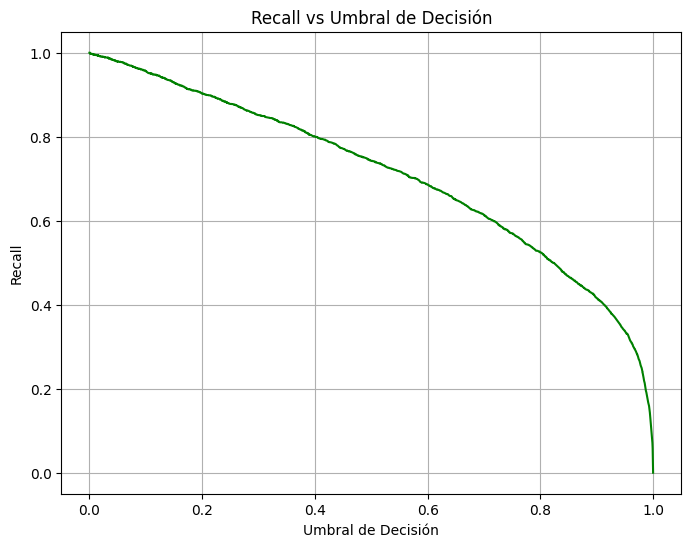

In [8]:
# Definir los hiperparámetros

param_grid = {
    'learning_rate': [0.05, 0.1, 0.15],  # Reducir la tasa de aprendizaje
    'n_estimators': [800],  # Aumentar el número de estimadores
    'max_depth': [8, 10],  # Reducir la profundidad de los árboles
    'scale_pos_weight': [1, 2],  # Ajustar para balance de clases
    'colsample_bytree': [0.8, 0.9],  # Ajustar número de características
    'subsample': [0.8],  # Usar una fracción de las muestras para cada árbol
    'gamma': [0.1],  # Mantener gamma bajo
    'base_score': [0.5],  # Mantener base_score en 0.5
}

# Almacenar los resultados

results = []

# Iterar sobre los parámetros

for params in product(*param_grid.values()):
    learning_rate, n_estimators, max_depth, scale_pos_weight, colsample_bytree, subsample, gamma, base_score = params
    model = XGBClassifier(
        learning_rate=float(learning_rate),
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=int(scale_pos_weight),
        colsample_bytree=float(colsample_bytree),
        subsample=float(subsample),
        gamma=float(gamma),
        base_score=float(base_score)
    )

    # Entrenar el modelo

    model.fit(X_train, y_train)

    # Predecir el modelo en los datos de prueba

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.4).astype(int)

    # Calcular las métricas

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Validación cruzada

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    mean_cv_score = np.mean(cv_scores)
    
    # Guardar los resultados

    results.append({
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'scale_pos_weight': scale_pos_weight,
        'colsample_bytree': colsample_bytree,
        'subsample': subsample,
        'gamma': gamma,
        'base_score': base_score,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,  # <-- Priorizar recall
        'roc_auc': roc_auc,
        'cv_recall': mean_cv_score  # <-- Guardar recall en validación cruzada
    })


# Convertir los resultados en un DataFrame

results_df = pd.DataFrame(results).sort_values(by=['recall', 'f1_score'], ascending=False)

# Mostrar los resultados

display(results_df.head(5))

# Seleccionar el mejor modelo

best_model_params = results_df.iloc[0]
best_model = XGBClassifier(
    learning_rate=best_model_params['learning_rate'],
    n_estimators=int(best_model_params['n_estimators']),
    max_depth=int(best_model_params['max_depth']),
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Entrenar el mejor modelo

best_model.fit(X_train, y_train)

# Predecir el modelo en los datos de prueba

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.4).astype(int)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - Mejor Modelo')
plt.show()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'Curva ROC - Mejor Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Graficar Recall vs Umbral de decisión
plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr, label='Recall', color='green')
plt.title('Recall vs Umbral de Decisión')
plt.xlabel('Umbral de Decisión')
plt.ylabel('Recall')
plt.grid(True)
plt.show()

### AdaBoost

,n_estimators,learning_rate,estimator_depth,accuracy,f1_score,recall,roc_auc,cv_score,train_score,overfitting
1,500,0.68,7,0.859702,0.858213,0.859702,0.934132,0.856226,0.908827,OK
0,500,0.67,7,0.855871,0.854843,0.855871,0.934194,0.855035,0.909397,OK
2,500,0.69,7,0.854628,0.853416,0.854628,0.931528,0.854362,0.895289,OK


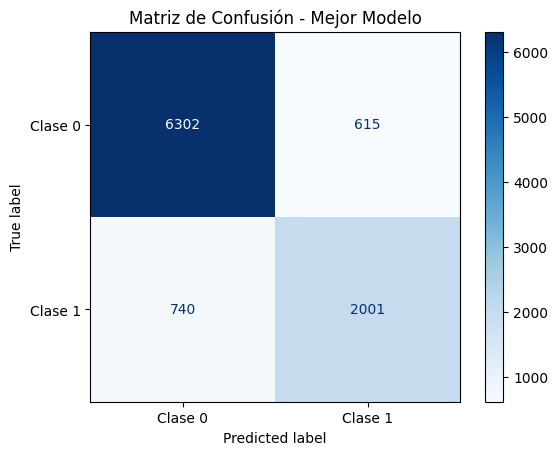

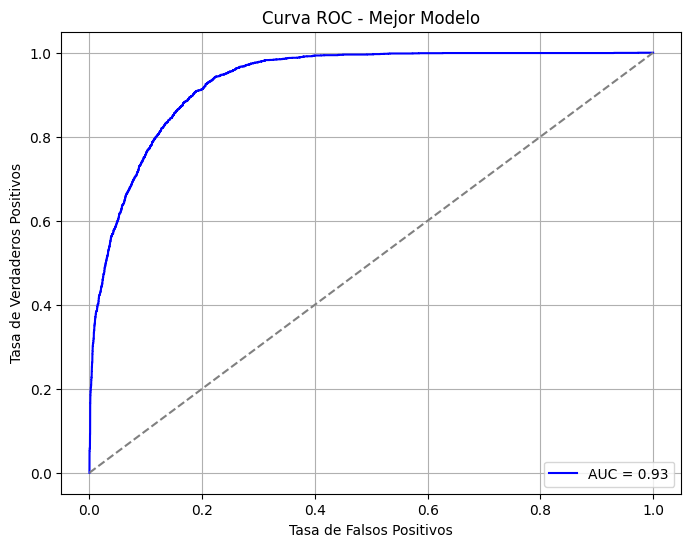

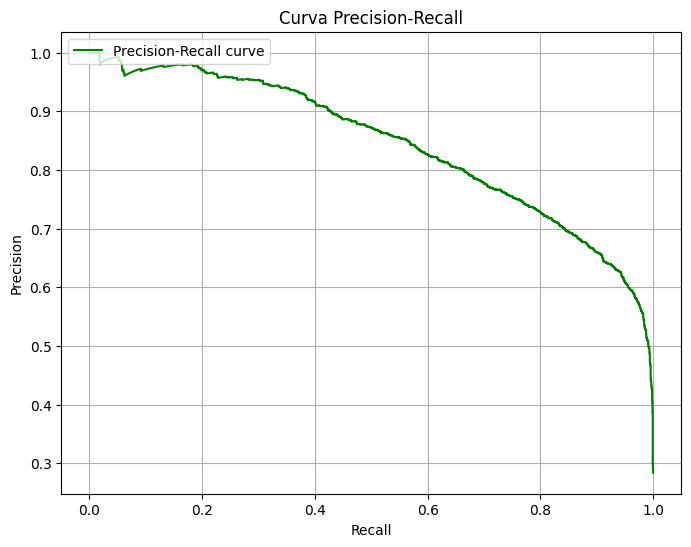

In [21]:
# Definir hiperparámetros a iterar
param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.67, 0.68, 0.69],
    'estimator': [DecisionTreeClassifier(max_depth=7)]
}

# Almacenar resultados
results = []

# Iterar sobre todas las combinaciones de hiperparámetros
for params in product(*param_grid.values()):
    (n_estimators, learning_rate, estimator) = params
    
    # Construir el modelo
    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        estimator=estimator,  # <--- Cambio aquí
        random_state=38
    )
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predecir
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba) if len(np.unique(y_test)) > 1 else None
    
    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_cv_score = np.mean(cv_scores)
    
    # Train Score
    train_score = model.score(X_train, y_train)
    
    # Evaluar sobreajuste
    if train_score > 1.5 * mean_cv_score:
        overfitting_warning = "SEVERE OVERFITTING"
    elif train_score > 1.2 * mean_cv_score:
        overfitting_warning = "DANGER"
    elif train_score > 1.1 * mean_cv_score:
        overfitting_warning = "MILD OVERFITTING"
    else:
        overfitting_warning = "OK"
    
    # Guardar resultados
    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'estimator_depth': estimator.max_depth,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,
        'roc_auc': roc_auc,
        'cv_score': mean_cv_score,
        'train_score': train_score,
        'overfitting': overfitting_warning
    })

# Convertir resultados a DataFrame y seleccionar los mejores modelos
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['f1_score', 'accuracy'], ascending=False)

# Seleccionar los mejores modelos sin sobreajuste
best_models = results_df[results_df['overfitting'] == 'OK'].head(3)

display(best_models)

# Entrenar el mejor modelo y visualizar métricas
best_model_params = best_models.iloc[0].to_dict()
best_model = AdaBoostClassifier(
    n_estimators=best_model_params['n_estimators'],
    learning_rate=best_model_params['learning_rate'],
    estimator=DecisionTreeClassifier(max_depth=best_model_params['estimator_depth']),  # <--- Cambio aquí
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - Mejor Modelo')
plt.show()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'Curva ROC - Mejor Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Graficar la Curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label='Precision-Recall curve')
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


### Gradient Boosting

In [ ]:
# Definir los parámetros de Gradient Boosting

param_grid = {
    'n_estimators': [300],  # Número de estimadores (árboles)
    'subsample': [1.0],  # Fracción de muestras usadas en cada árbol (submuestreo)
    'criterion': ['friedman_mse'],  # Criterio de división (friedman_mse y squared_error son comunes)
    'min_samples_split': [8,10],  # Mínimo número de muestras necesarias para dividir un nodo
    'min_samples_leaf': [10],  # Mínimo número de muestras requeridas en una hoja
    'max_depth': [3,10],  # Profundidad máxima de los árboles
   }

# Almacenar los resultados
results = []

# Iterar sobre los parámetros
for params in product(*param_grid.values()):
    n_estimators, subsample, criterion, min_samples_split, min_samples_leaf, max_depth= params
    
    # Crear el modelo Gradient Boosting con los parámetros proporcionados
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        criterion=criterion,
        random_state=42
    )

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predecir el modelo en los datos de prueba
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.4).astype(int)  # Ajustar el umbral de decisión

    # Calcular las métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    
    # Calcular ROC-AUC si hay más de una clase
    if len(np.unique(y_test)) > 1:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    mean_cv_score = np.mean(cv_scores)
    
    # Calcular Train Score
    train_score = model.score(X_train, y_train)
    
    # Determinar si hay sobreajuste
    if train_score > 1.5 * mean_cv_score:
        overfitting_warning = "SEVERE OVERFITTING"
    elif train_score > 1.2 * mean_cv_score:
        overfitting_warning = "DANGER"
    elif train_score > 1.1 * mean_cv_score:
        overfitting_warning = "MILD OVERFITTING"
    else:
        overfitting_warning = "OK"

    # Guardar los resultados
    results.append({
        'criterion': criterion,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'n_estimators': n_estimators,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,
        'roc_auc': roc_auc,
        'cv_score': mean_cv_score,
        'train_score': train_score,
        'overfitting': overfitting_warning
    })

# Convertir los resultados en un DataFrame y ordenar
results_df = pd.DataFrame(results).sort_values(by=['accuracy', 'f1_score'], ascending=False)

# Seleccionar el mejor modelo sin sobreajuste y optimizando F1 Score
best_models = results_df[results_df['overfitting'] == 'OK'].head(3)

# Mostrar los mejores resultados
from IPython.display import display
display(best_models)

# Matriz de confusión y Curvas ROC/Precision-Recall del mejor modelo
if not best_models.empty:
    best_model_params = best_models.iloc[0].to_dict()
    best_model = GradientBoostingClassifier(
        n_estimators=best_model_params["n_estimators"],
        max_depth=best_model_params["max_depth"],
        min_samples_split=best_model_params["min_samples_split"],
        min_samples_leaf=best_model_params["min_samples_leaf"],
        criterion=best_model_params["criterion"],
        random_state=42
    )
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Matriz de Confusión
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Matriz de Confusión - {best_model_params["criterion"]}')
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {best_model_params["criterion"]}')
    plt.legend()
    plt.show()

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.figure()
    plt.plot(recall, precision, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Curva Precision-Recall - {best_model_params["criterion"]}')
    plt.legend()
    plt.show()
else:
    print("No suitable model found without overfitting.")